In [10]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [11]:

df = pd.read_excel("Dataset for Data Analytics.xlsx")

In [12]:
df.drop(columns=[
    'OrderID',
    'CustomerID',
    'ShippingAddress',
    'TrackingNumber'
], inplace=True)

In [13]:
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

df.drop('Date', axis=1, inplace=True)

In [14]:
df.isnull().sum()

Product             0
Quantity            0
UnitPrice           0
PaymentMethod       0
OrderStatus         0
ItemsInCart         0
CouponCode        309
ReferralSource      0
TotalPrice          0
Year                0
Month               0
Day                 0
dtype: int64

In [15]:
print(df.columns)

Index(['Product', 'Quantity', 'UnitPrice', 'PaymentMethod', 'OrderStatus',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice', 'Year',
       'Month', 'Day'],
      dtype='str')


In [16]:
df = pd.get_dummies(
    df,
    columns=[
        'Product',
        'PaymentMethod',
        'OrderStatus',
        'CouponCode',
        'ReferralSource'
    ],
    drop_first=True
)

In [17]:
df.head()

,Quantity,UnitPrice,ItemsInCart,TotalPrice,Year,Month,Day,Product_Desk,Product_Laptop,Product_Monitor,...,OrderStatus_Delivered,OrderStatus_Pending,OrderStatus_Returned,OrderStatus_Shipped,CouponCode_SAVE10,CouponCode_WINTER15,ReferralSource_Facebook,ReferralSource_Google,ReferralSource_Instagram,ReferralSource_Referral
0,5,570.62,7,2853.10,2023,1,4,False,False,True,...,False,False,False,True,True,False,False,False,True,False
1,2,151.35,3,302.70,2024,8,23,False,False,False,...,False,False,False,True,True,False,False,False,False,True
2,5,550.68,8,2753.40,2024,2,27,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,1,273.19,5,273.19,2023,10,15,False,False,False,...,False,False,True,False,True,False,True,False,False,False
4,4,626.01,8,2504.04,2025,5,8,False,False,False,...,True,False,False,False,True,False,False,False,False,False


In [18]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

In [19]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

In [20]:
print(pca_data.shape)

(1200, 2)


In [21]:
wcss = []

for i in range(1, 11):
    km = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    km.fit(pca_data)

    wcss.append(km.inertia_)

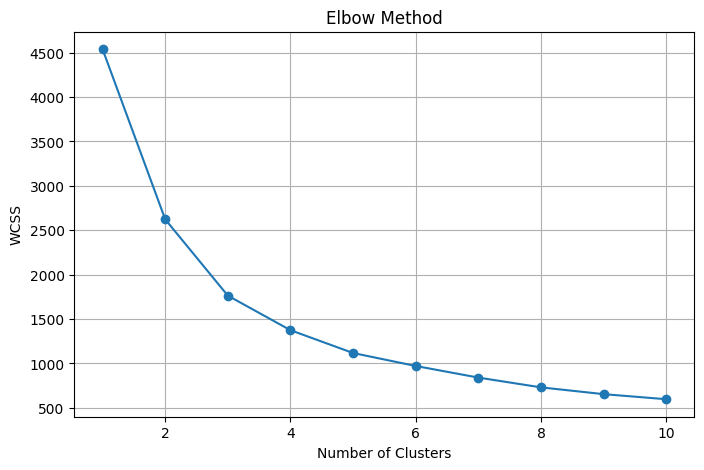

In [22]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.grid(True)

plt.show()

In [23]:
for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(pca_data)

    score = silhouette_score(pca_data, labels)

    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.3780
K = 3, Silhouette Score = 0.3737
K = 4, Silhouette Score = 0.3544
K = 5, Silhouette Score = 0.3499
K = 6, Silhouette Score = 0.3362
K = 7, Silhouette Score = 0.3381
K = 8, Silhouette Score = 0.3417
K = 9, Silhouette Score = 0.3349
K = 10, Silhouette Score = 0.3353


In [24]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(pca_data)

In [25]:
df['Cluster'].value_counts()

Cluster
1    359
2    338
0    267
3    236
Name: count, dtype: int64

In [26]:
df.groupby('Cluster').mean(numeric_only=True)

,Quantity,UnitPrice,ItemsInCart,TotalPrice,Year,Month,Day,Product_Desk,Product_Laptop,Product_Monitor,...,OrderStatus_Delivered,OrderStatus_Pending,OrderStatus_Returned,OrderStatus_Shipped,CouponCode_SAVE10,CouponCode_WINTER15,ReferralSource_Facebook,ReferralSource_Google,ReferralSource_Instagram,ReferralSource_Referral
Cluster,,,,,,,,,,,,,,,,,,,,,
0,1.883895,219.203558,4.179775,359.209288,2023.591760,6.932584,16.876404,0.202247,0.134831,0.161049,...,0.164794,0.284644,0.299625,0.052434,0.127341,0.385768,0.168539,0.142322,0.374532,0.067416
1,2.019499,361.762061,4.183844,653.352563,2024.030641,5.295265,14.612813,0.083565,0.094708,0.103064,...,0.222841,0.064067,0.153203,0.362117,0.362117,0.125348,0.192201,0.233983,0.052925,0.334262
2,3.772189,335.149911,6.541420,1153.279467,2023.653846,6.207101,16.340237,0.186391,0.192308,0.142012,...,0.174556,0.281065,0.230769,0.103550,0.147929,0.289941,0.195266,0.192308,0.316568,0.100592
3,4.372881,533.960593,7.427966,2307.165466,2023.728814,5.694915,16.474576,0.097458,0.161017,0.148305,...,0.203390,0.182203,0.144068,0.237288,0.305085,0.194915,0.203390,0.228814,0.139831,0.211864


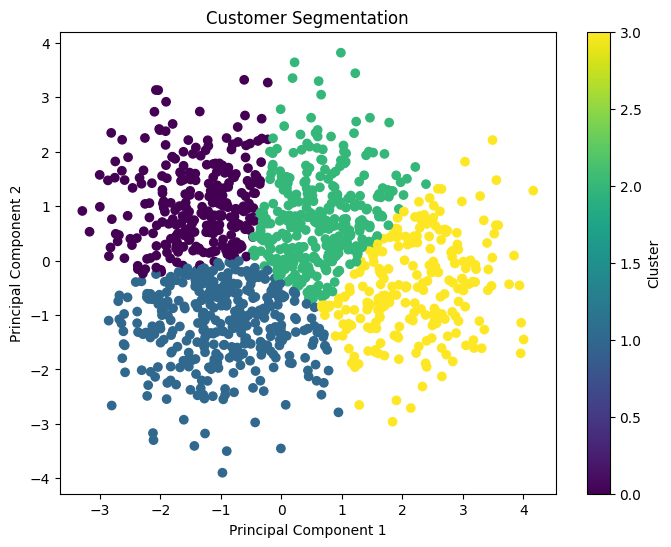

In [27]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=df['Cluster'],
    cmap='viridis'
)

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title("Customer Segmentation")

plt.colorbar(label="Cluster")

plt.show()

In [28]:
df.to_excel("Customer_Segmentation_Output.xlsx", index=False)

In [29]:
import os

print(os.getcwd())

C:\Users\MADHU\Customer Segmentation Project
